<h1 align = "center">Revision 1</h1>

In [89]:
#imports the necessary lib

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

<hr>

<h2 style = "color:red; text-align:center">Part 1: Load and Explore the Titanic Dataset</h2>

### Q1. Load & Inspect
1. Load the Titanic dataset using sns.load_dataset('titanic') and store it in a variable called df .
2. Print the shape of the dataset.
3. Display the first 6 rows.
4. Print the column names.

### ANSWER

In [2]:
#1 
df = sns.load_dataset('Titanic')

#2
print(df.shape)

#3
print(df.head(6))

#6
print(df.columns)

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   
5         0       3    male   NaN      0      0   8.4583        Q  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
5    man        True  NaN   Queenstown    no   True  
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'em

### Q2. Data Types & Missing Values
1. Use .info() to print column data types and non-null counts.
2. Print the number of missing values per column using .isnull().sum().
3. Which column has the most missing values? Write your answer in a Markdown cell.

### ANSWER

In [3]:
#1
print(df.info())

#2
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

#### Answer Q2.3:
Deck

### Q3. Basic Statistics
1. Use .describe() to display summary statistics for numeric columns.
2. From the output, answer in a Markdown cell:
- What is the mean age of passengers?
- What is the maximum fare paid?
- What percentage of passengers survived? (Hint: look at the survived mean, it represents the survival rate)

### ANSWER

In [4]:
#1
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Answer Q3.2:
- the mean age - 29.70
- the max fare paid - 512.32
- survival rate - 38.38%

### Q4. Duplicates & Categorical Summary
1. Check how many duplicate rows exist in the dataset.
2. Use .describe(include=['object', 'category']) to get a summary of categorical columns.
3. From the output, answer in a Markdown cell:
- What is the most common sex in the dataset and how many rows does it appear in?
- What is the most common embarkation port?

### ANSWER

In [5]:
#1 
df.duplicated().sum()

#2
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


#### Answer Q4.3:
- male, 577
- S

<hr>

<h2 style = 'color:rgb(50,100,200); text-align:center'>Part 2: Data Cleaning</h2>

### Q5. Handle Missing Values
Create a new DataFrame called df_clean and apply the following cleaning steps in order:
1. Drop the deck column (too many missing values).
2. Fill missing values in the age column with the median age.
3. Fill missing values in the embarked column with the mode (most frequent value).
4. Fill missing values in the embark_town column with its mode.
5. After cleaning, print .isnull().sum() to confirm no missing values remain.

### ANSWER

In [6]:
#make a copy
df_clean = df.copy()

#1
df_clean = df_clean.drop(columns = ['deck'])

#2
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

#3
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

#4
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

#5
df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### Q6. Remove Duplicates & Redundant Columns
Continue working with df_clean :
1. Remove duplicate rows from df_clean using drop_duplicates(inplace=True).
2. Drop the columns 'alive' and 'embark_town'- REASON - they are redundant (duplicated information from survived
and embarked ).
3. Print the shape before and after to show how many rows were removed.
4. Display the first 5 rows of the cleaned DataFrame.

### ANSWERS

In [7]:
#print shape before
print(df_clean.shape)

(891, 14)


In [8]:
#1
df_clean.drop_duplicates(inplace=True)

#2
df_clean.drop(columns = ['alive', 'embark_town'], inplace = True)

#3
print(df_clean.shape)

#4
print(df_clean.head(5))

(775, 12)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  alone  
0    man        True  False  
1  woman       False  False  
2  woman       False   True  
3  woman       False  False  
4    man        True   True  


### Q7. Outlier Detection
1. Create a boxplot for the fare column to visually identify outliers.
2. Use the IQR method to calculate the upper bound for outliers:
- Q1 = fare.quantile(0.25), Q3 = fare.quantile(0.75)
- IQR = Q3 - Q1
- upper_bound = Q3 + 1.5 * IQR
3. Print how many rows have a fare above the upper bound.
4. Create a new column fare_capped that clips the fare at the upper bound using .clip(upper=upper_bound).

### ANSWER

<function matplotlib.pyplot.show(close=None, block=None)>

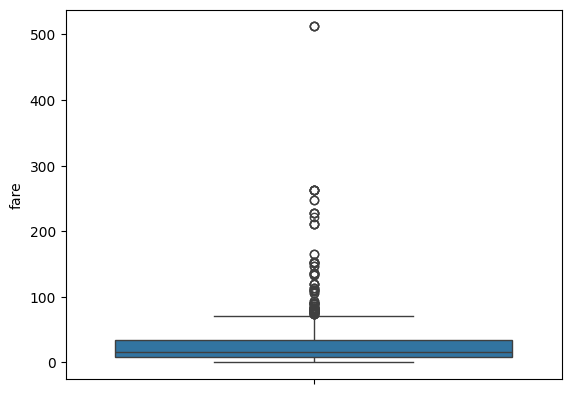

In [9]:
#1
sns.boxplot(y = df_clean['fare'])
plt.show

In [10]:
#2
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + IQR * 1.5

#3
df_clean[df_clean['fare'] > upper_bound].shape[0]

102

In [18]:
#4
df_clean['fare_capped'] = df_clean['fare'].clip(upper = upper_bound)

<hr>

<h2 style = "text-align:center;color:rgb(50,100,200)">Part 3: Filtering, Sorting & Grouping</h2>

### Q8. Filtering

Using df_clean :
1. Filter passengers who survived ( survived == 1 ) AND were in First class ( class == 'First' ). How many are there?
2. Filter passengers who were older than 60. Print how many there are and display their names if the column exists, otherwise
display the filtered DataFrame.
3. Filter passengers who paid a fare above $50 and were female. How many rows match?

### ANSWER

In [22]:
#1
df_clean[(df_clean['survived'] == 1)&(df_clean['class'] == 'First')].shape[0]

133

In [25]:
#2
df_clean[df_clean['age']>60]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,fare_capped
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,True,10.50000
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,False,61.97920
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,True,34.65420
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,True,7.75000
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,True,33.50000
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,True,26.55000
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,False,73.41975
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,True,7.75000
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,True,6.23750
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,False,73.41975


In [34]:
#3
df_clean[(df_clean['fare'] > 50)&(df_clean['sex'] == 'female')].shape[0]

84

### Q9. Sorting
Using df_clean :
1. Sort the DataFrame by fare in descending order and display the top 5 rows (only columns: sex , age, class , fare ,
survived ).
2. Sort by age in ascending order and display the 5 youngest passengers.
3. In a Markdown cell, state one observation from each sorted result.

### ANSWER

In [37]:
#1
df_clean.sort_values(by = 'fare', ascending = False)[['sex', 'age', 'class', 'fare', 'survived']].head(5)

,sex,age,class,fare,survived
258,female,35.0,First,512.3292,1
737,male,35.0,First,512.3292,1
679,male,36.0,First,512.3292,1
88,female,23.0,First,263.0000,1
341,female,24.0,First,263.0000,1


In [36]:
#2
df_clean.sort_values(by = 'age', ascending = True).head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,fare_capped
803,1,3,male,0.42,0,1,8.5167,C,Third,child,False,False,8.5167
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,False,14.5000
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,False,19.2583
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,False,18.7500
78,1,2,male,0.83,0,2,29.0000,S,Second,child,False,False,29.0000


#### Your observations:
- Passengers who paid the highest fares had a 100% survival rate, suggesting a strong correlation between socio-economic status and survival chances.
- The youngest passengers survived, which indicates that the "women and children first" policy was actively practiced during the evacuation.

### Q10. GroupBy & Aggregation
Using df_clean :
1. Use .groupby('sex')['survived'].mean() to find the survival rate by sex. Round to 2 decimal places.
2. Use .groupby('class')['survived'].mean() to find the survival rate by passenger class.
3. Use .groupby('class')['fare'].mean() to find the average fare per class.
4. In a Markdown cell, write two observations from the results above.

### ANSWER

In [45]:
#1
df_clean.groupby('sex')['survived'].mean().round(2)

sex
female    0.74
male      0.22
Name: survived, dtype: float64

In [46]:
#2
df_clean.groupby('class')['survived'].mean()

class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64

In [47]:
#3
df_clean.groupby('class')['fare'].mean() 

class
First     85.675199
Second    21.889279
Third     13.588850
Name: fare, dtype: float64

#### Your observations:
1. Female passengers had a significantly higher survival rate compared to male passengers.
2. Passengers in the first and second classes had higher survival rates compared to those in the third class.

<hr>

<h2 style = 'color:rgb(50,100,200); text-align:center'>Part 4: Visualization</h2>

### Q11. Histogram & Count Plot
Create a figure with two subplots side by side ( figsize=(12, 4) ):
- Left subplot: Histogram of age using sns.histplot with kde=True and bins=20 . Title: 'Age Distribution'.
- Right subplot: Count plot of survived using sns.countplot . Title: 'Survival Count'. <br>
Use plt.tight_layout() and plt.show().

### ANSWER

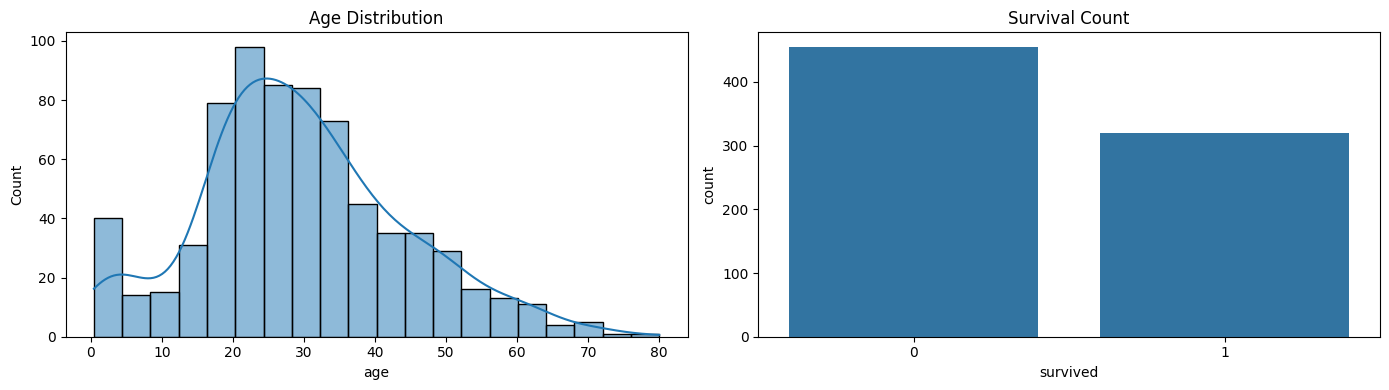

In [51]:
plt.figure(figsize = (14,4))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde = True, bins = 20)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x = 'survived', data = df_clean)
plt.title('Survival Count')

plt.tight_layout()
plt.show()

### Q12. Categorical Plots
Create a figure with two subplots side by side ( figsize=(12, 5) ):
- Left: sns.countplot with x='sex' and hue='survived' . Title: 'Survival by Sex'.
- Right: sns.countplot with x='class' and hue='survived' . Title: 'Survival by Class'.<br>
  In a Markdown cell below, interpret each plot in one sentence each.
### ANSWER

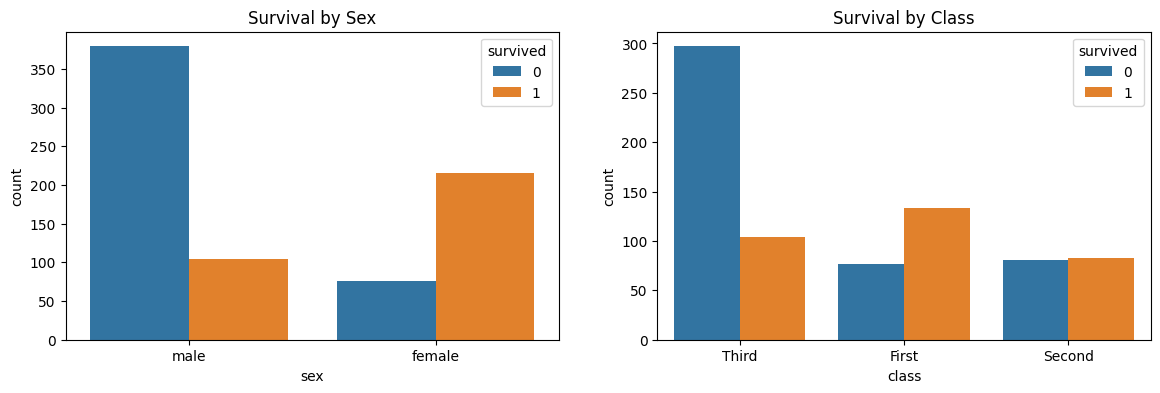

In [53]:
plt.figure(figsize = (14, 4))

plt.subplot(1, 2, 1)
sns.countplot(x = 'sex', hue = 'survived', data = df_clean)
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(x = 'class', hue = 'survived', data = df_clean)
plt.title('Survival by Class')

plt.show()

#### Your interpretations:
- The vast majority of male passengers did not survive, while the majority of female passengers were saved, confirming gender as a primary factor in survival priority.
- Passengers in First Class had the highest survival probability, whereas those in Third Class faced the highest mortality rate. Second Class passengers had a nearly equal distribution of survival and loss.

### Q13. Boxplot & Scatter Plot
1. Create a boxplot using sns.boxplot(x='class', y='age', hue='survived', data=df_clean) . Title: 'Age by Class
and Survival' .
2. Create a scatter plot using sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean,
alpha=0.6) . Title: 'Age vs Fare (Capped) by Survival'.
3. In a Markdown cell, write one observation from each plot.
### ANSWER

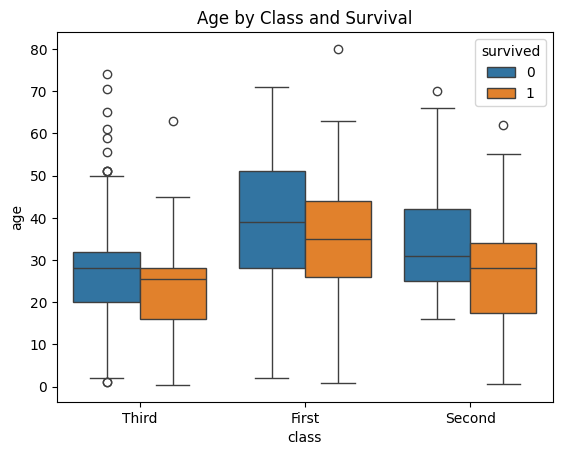

In [55]:
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title('Age by Class and Survival')
plt.show()

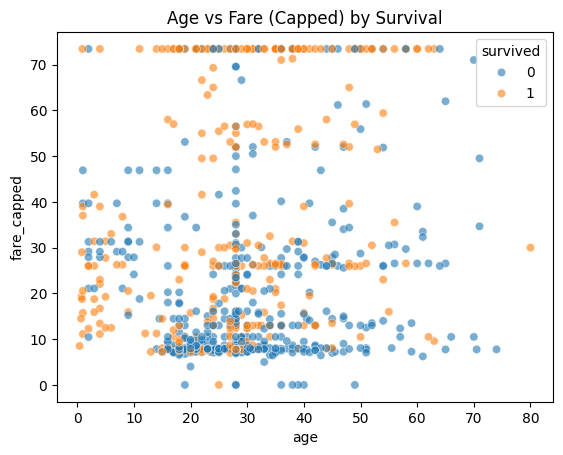

In [58]:
sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)
plt.title('Age vs Fare (Capped) by Survival')
plt.show()

#### Your observations:
- Passenger age was a key factor in survival. Across all classes, the median age of survivors is generally lower than that of non-survivors. Additionally, the first class shows a significantly older passenger demographic compared to the second and third classes, while the third class contains a high concentration of younger passengers and outliers.
- Passengers who paid the highest fares mostly survived.

### Q14. Correlation Heatmap
1. Select all numeric columns from df_clean using select_dtypes(include=np.number).
2. Compute the correlation matrix using .corr().
3. Plot it as a heatmap using sns.heatmap(... annot=True, cmap='coolwarm', center=0) . Set figsize=(8, 6) . Title:
'Correlation Heatmap'.
4. In a Markdown cell, identify the two features most positively correlated with survival.

### ANSWER

Text(0.5, 1.0, 'Correlation Heatmap')

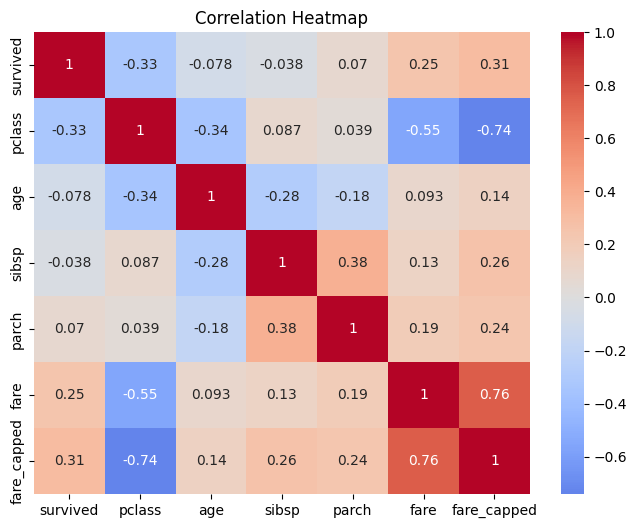

In [62]:
#1
plt.figure(figsize=(8,6))
num_cols = df_clean.select_dtypes(include=np.number)
corr_mtrx = num_cols.corr()
sns.heatmap(corr_mtrx, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

#### Answer Q14.4:
parch, fare_capped(fare)

<hr>

<h2 style = 'color:rgb(50,100,200); text-align:center'>Part 5: Tips Dataset: Filtering & Grouping</h2>

### Q15. Load and Filter the Tips Dataset
1. Load the tips dataset: tips = sns.load_dataset('tips').
2. Display the first 5 rows and print the shape.
3. Filter only dinner orders where the total bill is above $20. How many rows match?
4. From those filtered rows, find the average tip.
### ANSWER

In [68]:
#1
tips = sns.load_dataset('tips')
print(tips.head(5))
#2
print(tips.shape)
#3
bill_gt_20 = tips[tips['total_bill']>20]
print(bill_gt_20.shape[0])
#4
print(bill_gt_20['tip'].mean())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)
97
3.929484536082474


### Q16. Grouping the Tips Dataset
Using the full tips DataFrame:
1. Use .groupby('day')['tip'].mean() to find the average tip by day. Sort from highest to lowest.
2. Use .groupby('smoker')['tip'].mean() to compare tips between smokers and non-smokers.
3. In a Markdown cell, answer: Do smokers tip more or less on average?
### ANSWER

In [73]:
#1
tips.groupby('day', observed = True)['tip'].mean().sort_values(ascending = False)

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

In [75]:
#2
tips.groupby('smoker', observed=True)['tip'].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

#### Answer Q16.3:
Yes

### Q17. Visualize the Tips Dataset
Create a figure with three subplots ( figsize=(15, 4) ):
- Left: Scatter plot of total_bill vs tip (use plt.scatter ). Title: 'Tip vs Total Bill'.
- Center: Bar plot of average tip by day (use .plot(kind='bar') on the grouped result). Title: 'Average Tip by Day'.
- Right: Histogram of tip with bins=15 and edgecolor='k' . Title: 'Tip Distribution'. <br>
Add axis labels and plt.tight_layout().

### ANSWER

<Figure size 1500x400 with 0 Axes>

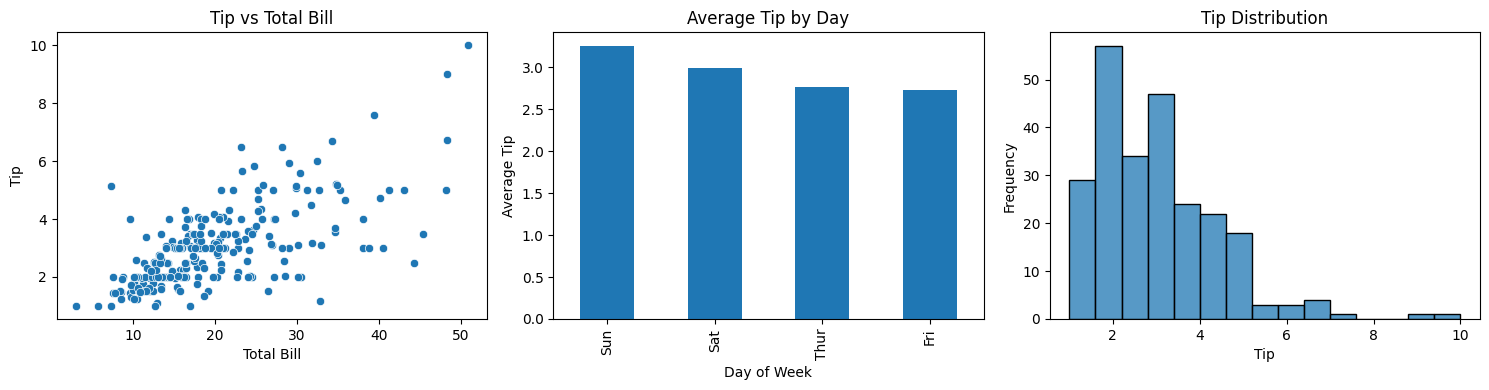

In [81]:
plt.figure(figsize = (15,4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x='total_bill', y='tip', data=tips, ax=axes[0])
axes[0].set_title('Tip vs Total Bill')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip')

tips.groupby('day', observed=True)['tip'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Tip by Day')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Tip')

sns.histplot(data=tips, x='tip', bins=15, edgecolor='k', ax=axes[2])
axes[2].set_title('Tip Distribution')
axes[2].set_xlabel('Tip')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Linear Regression on Tips
Using the tips dataset:
1. Extract X = total_bill (reshape to column: tips[['total_bill']].values ) and y = tip
( tips[['tip']].values ).
2. Train a LinearRegression model from sklearn.linear_model.
3. Print the coefficient and intercept. Interpret them in a sentence: "For every extra 1 dollar on the bill, the tip increases by..."
4. Plot the data as a scatter plot and overlay the regression line in red.
5. Predict the tip for a total bill of $30.

### ANSWER

For every extra 1 dollar on the bill, the tip increases by 0.11 dollars.


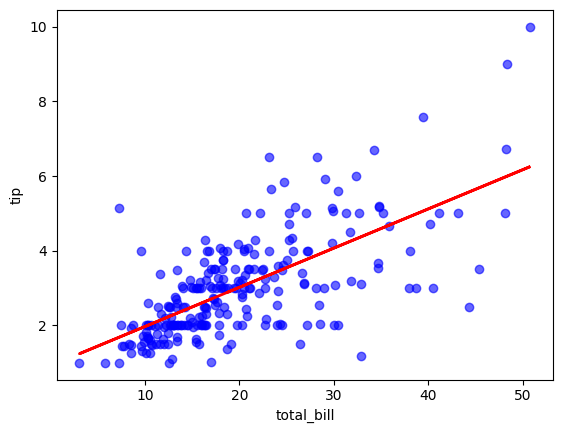

Predicted tip for a $30 bill: [[4.07100514]]


In [101]:
#1
X = tips[['total_bill']].values
y = tips[['tip']].values

#2
model = LinearRegression()
model.fit(X, y)

#3
coef = model.coef_[0][0]
intercept = model.intercept_[0]
print(f"For every extra 1 dollar on the bill, the tip increases by {coef:.2f} dollars.")

#4
y_pred = model.predict(X)
plt.scatter(X, y, color = "blue", alpha = 0.6)
plt.plot(X, y_pred, color = "red", linewidth = 2)
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()

#5
predicted_tip = model.predict([[30]])
print(f"Predicted tip for a $30 bill: {predicted_tip}")